# Weather-Related Flight Delay EDA


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})

BASE = Path('../../Merged_Data')
df   = pd.read_csv(BASE / 'merged_flights.csv', low_memory=False)

# ── Core subsets ───────────────────────────────────────────────────
df_delayed         = df[df['IS_Delay'] == 1].copy()               # any delayed flight
df_weather_delayed = df[(df['IS_Delay'] == 1) & (df['weather_delay'] > 0)].copy()  # delayed AND weather contributed

total               = len(df)
total_delayed       = len(df_delayed)
total_wx_delayed    = len(df_weather_delayed)

print(f'Total flights                          : {total:>10,}')
print(f'Delayed flights        (IS_Delay=1)    : {total_delayed:>10,}  ({total_delayed/total*100:.1f}% of all)')
print(f'Weather-caused delays  (weather_delay>0): {total_wx_delayed:>10,}  ({total_wx_delayed/total_delayed*100:.1f}% of delayed)')

Total flights                          :  1,343,443
Delayed flights        (IS_Delay=1)    :    393,696  (29.3% of all)
Weather-caused delays  (weather_delay>0):     17,412  (4.4% of delayed)


## 1. How Many Delayed Flights Were Weather-Caused?

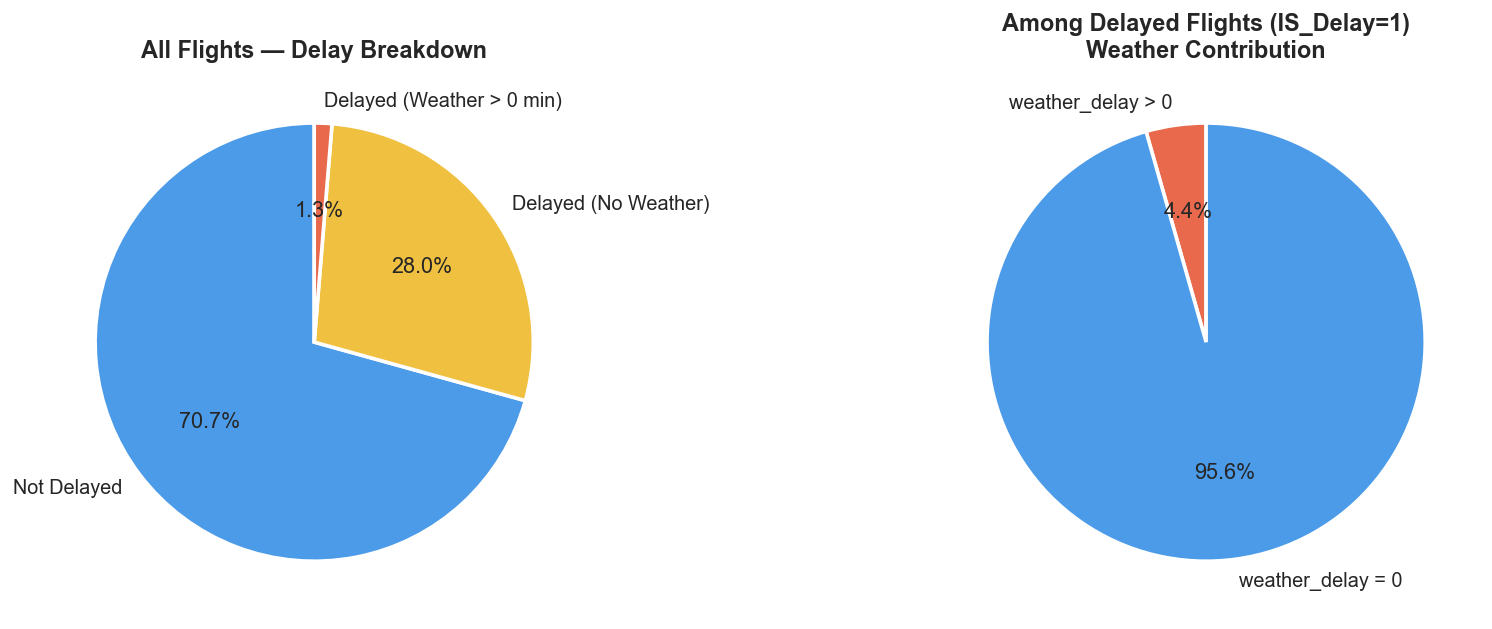

In [2]:
not_delayed         = total - total_delayed
delayed_no_weather  = total_delayed - total_wx_delayed

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All flights breakdown
axes[0].pie(
    [not_delayed, delayed_no_weather, total_wx_delayed],
    labels=['Not Delayed', 'Delayed (No Weather)', 'Delayed (Weather > 0 min)'],
    autopct='%1.1f%%',
    colors=['#4C9BE8', '#F0C040', '#E8694C'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('All Flights — Delay Breakdown', fontsize=13, fontweight='bold')

# Among delayed only: weather > 0 vs not
axes[1].pie(
    [total_wx_delayed, delayed_no_weather],
    labels=['weather_delay > 0', 'weather_delay = 0'],
    autopct='%1.1f%%',
    colors=['#E8694C', '#4C9BE8'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Among Delayed Flights (IS_Delay=1)\nWeather Contribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Weather Delay Minutes Distribution (Among Weather-Caused Delays)

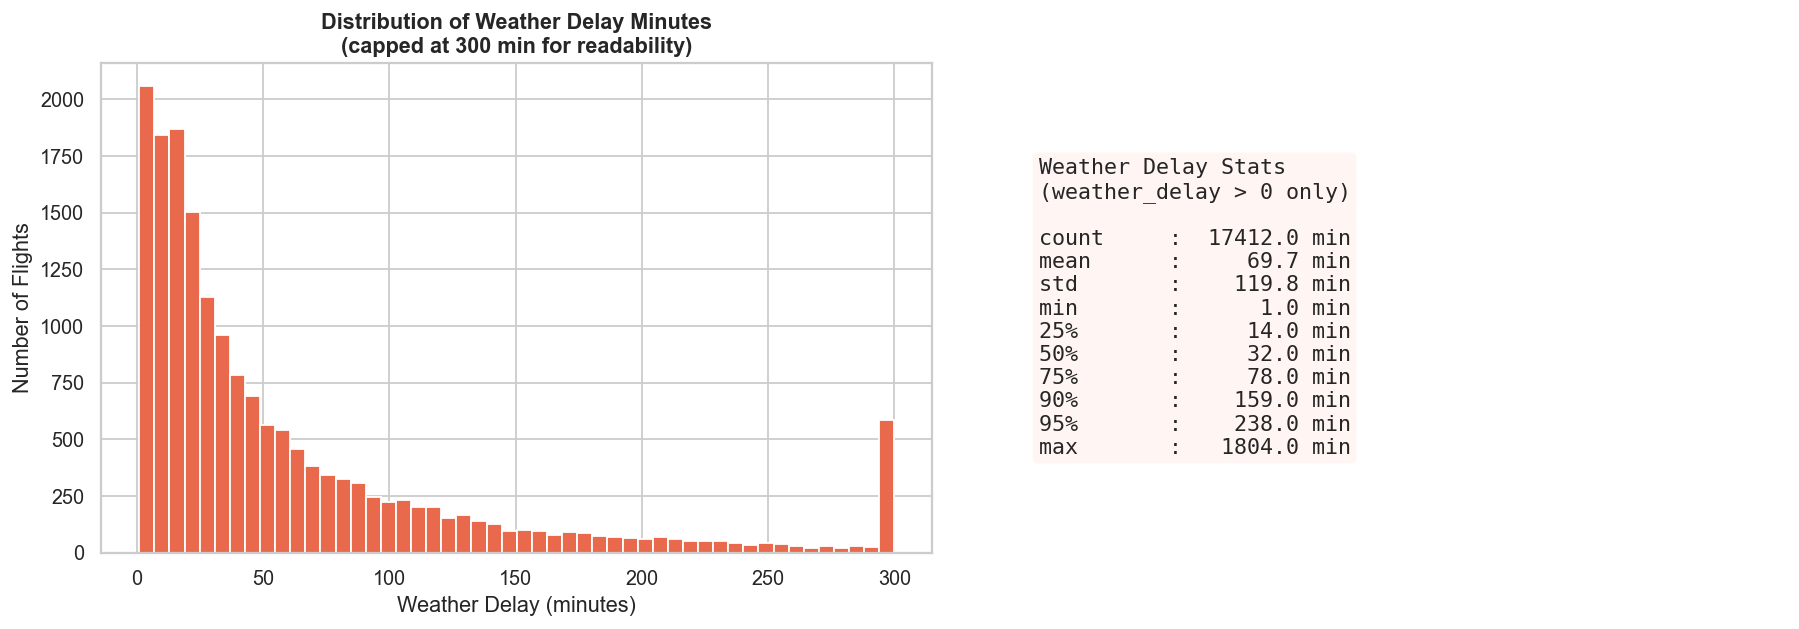

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of weather delay minutes
axes[0].hist(df_weather_delayed['weather_delay'].clip(upper=300),
             bins=50, color='#E8694C', edgecolor='white')
axes[0].set_title('Distribution of Weather Delay Minutes\n(capped at 300 min for readability)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Weather Delay (minutes)')
axes[0].set_ylabel('Number of Flights')

# Stats
stats = df_weather_delayed['weather_delay'].describe(percentiles=[.25,.5,.75,.90,.95])
axes[1].axis('off')
stat_text = '\n'.join([f'{k:<10}: {v:>8.1f} min' for k, v in stats.items()])
axes[1].text(0.1, 0.5, f'Weather Delay Stats\n(weather_delay > 0 only)\n\n{stat_text}',
             transform=axes[1].transAxes, fontsize=12,
             verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#FFF3F0', alpha=0.8))

plt.tight_layout()
plt.show()

## 3. Weather vs Other Delay Types (Among All Delayed Flights)

Among IS_Delay=1 flights, how many had each delay type > 0:
                     flights_affected  pct_of_delayed
carrier_delay                  152561           38.75
late_aircraft_delay            142778           36.27
nas_delay                      138346           35.14
weather_delay                   17412            4.42
security_delay                   1459            0.37


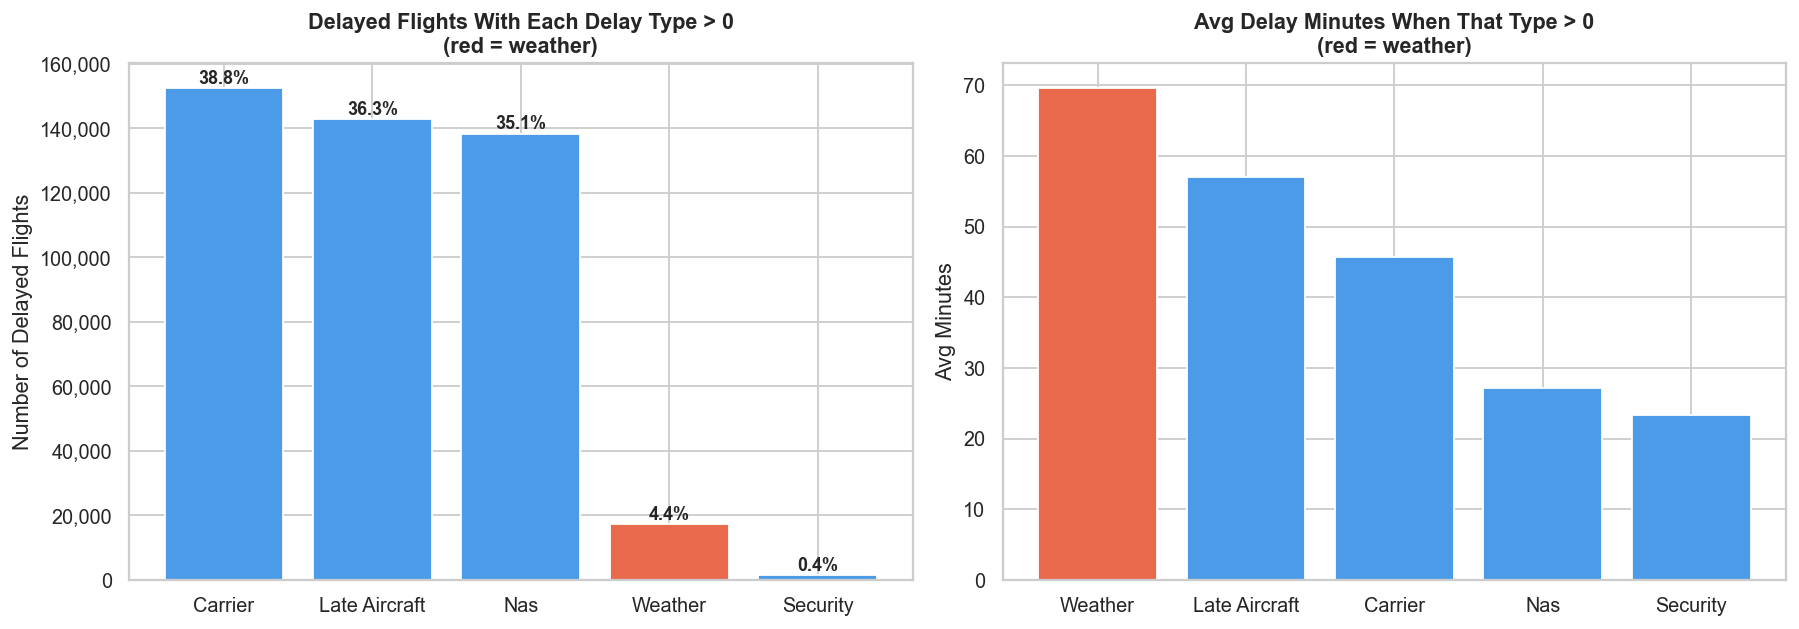

In [ ]:
delay_cols = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

# Count of delayed flights where each type > 0
delay_counts = (df_delayed[delay_cols] > 0).sum().sort_values(ascending=False)
delay_pct    = (delay_counts / total_delayed * 100).round(2)

print('Among IS_Delay=1 flights, how many had each delay type > 0:')
print(pd.DataFrame({'flights_affected': delay_counts, 'pct_of_delayed': delay_pct}).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = ['#E8694C' if 'weather' in c else '#4C9BE8' for c in delay_counts.index]
bars = axes[0].bar(
    [c.replace('_delay','').replace('_',' ').title() for c in delay_counts.index],
    delay_counts.values, color=bar_colors, edgecolor='white'
)
for bar, pct in zip(bars, delay_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Delayed Flights With Each Delay Type > 0\n(red = weather)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Delayed Flights')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

avg_mins = {col: df_delayed[df_delayed[col] > 0][col].mean() for col in delay_cols}
avg_series = pd.Series(avg_mins).sort_values(ascending=False)
bar_colors2 = ['#E8694C' if 'weather' in c else '#4C9BE8' for c in avg_series.index]
axes[1].bar(
    [c.replace('_delay','').replace('_',' ').title() for c in avg_series.index],
    avg_series.values, color=bar_colors2, edgecolor='white'
)
axes[1].set_title('Avg Delay Minutes When That Type > 0\n(red = weather)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Minutes')

plt.tight_layout()
plt.show()

## 4. Weather Data Coverage

In [5]:
# Of all weather-caused delayed flights, how many have sensor data?
wx_coverage = df_weather_delayed['Weather_Data_Present'].value_counts()
print('Weather_Data_Present among weather-caused delayed flights:')
print(wx_coverage.to_string())

# Subset for condition analysis: weather-caused delays WITH sensor data
df_wx_sensor = df_weather_delayed[df_weather_delayed['Weather_Data_Present'] == 'Yes'].copy()
# Non-weather delayed WITH sensor data (for comparison)
df_no_wx_sensor = df[(df['IS_Delay'] == 1) &
                     (df['weather_delay'] == 0) &
                     (df['Weather_Data_Present'] == 'Yes')].copy()

print(f'\nWeather-delayed with sensor data : {len(df_wx_sensor):,}')
print(f'Non-weather-delayed with sensor  : {len(df_no_wx_sensor):,}')

Weather_Data_Present among weather-caused delayed flights:
Weather_Data_Present
No     16165
Yes     1247

Weather-delayed with sensor data : 1,247
Non-weather-delayed with sensor  : 30,033


## 5. Weather Conditions: weather_delay > 0 vs weather_delay = 0 (among IS_Delay=1)

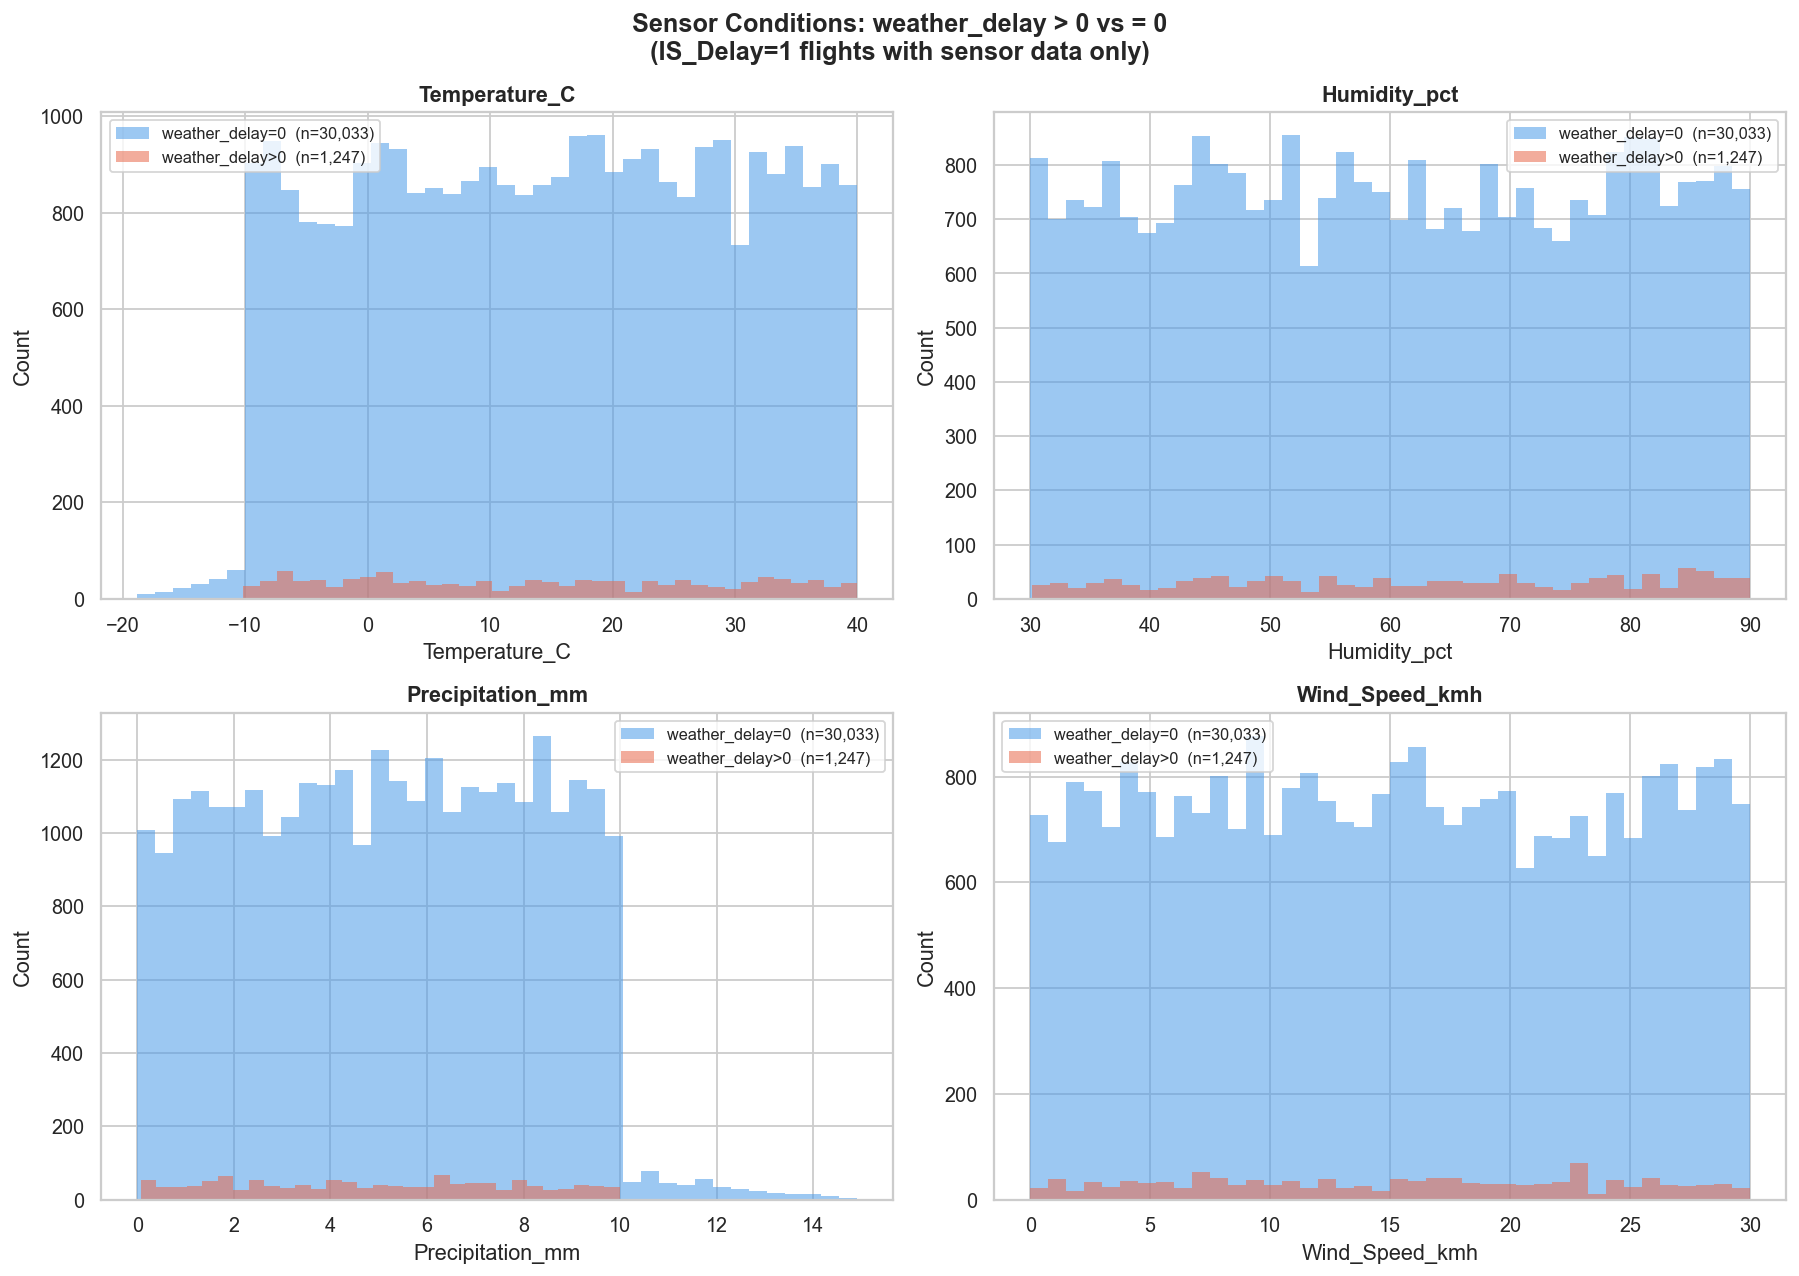

In [6]:
weather_vars = ['Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(weather_vars):
    no_wx  = df_no_wx_sensor[var].dropna()
    yes_wx = df_wx_sensor[var].dropna()
    axes[i].hist(no_wx,  bins=40, alpha=0.55, label=f'weather_delay=0  (n={len(no_wx):,})',  color='#4C9BE8', edgecolor='none')
    axes[i].hist(yes_wx, bins=40, alpha=0.55, label=f'weather_delay>0  (n={len(yes_wx):,})', color='#E8694C', edgecolor='none')
    axes[i].set_title(var, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

plt.suptitle('Sensor Conditions: weather_delay > 0 vs = 0\n(IS_Delay=1 flights with sensor data only)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Average Conditions — Weather-Caused vs Non-Weather Delays

Average sensor conditions (IS_Delay=1 flights):
                  weather_delay > 0  weather_delay = 0
Temperature_C                 14.00              15.00
Humidity_pct                  61.92              60.13
Precipitation_mm               4.92               5.18
Wind_Speed_kmh                14.97              15.00


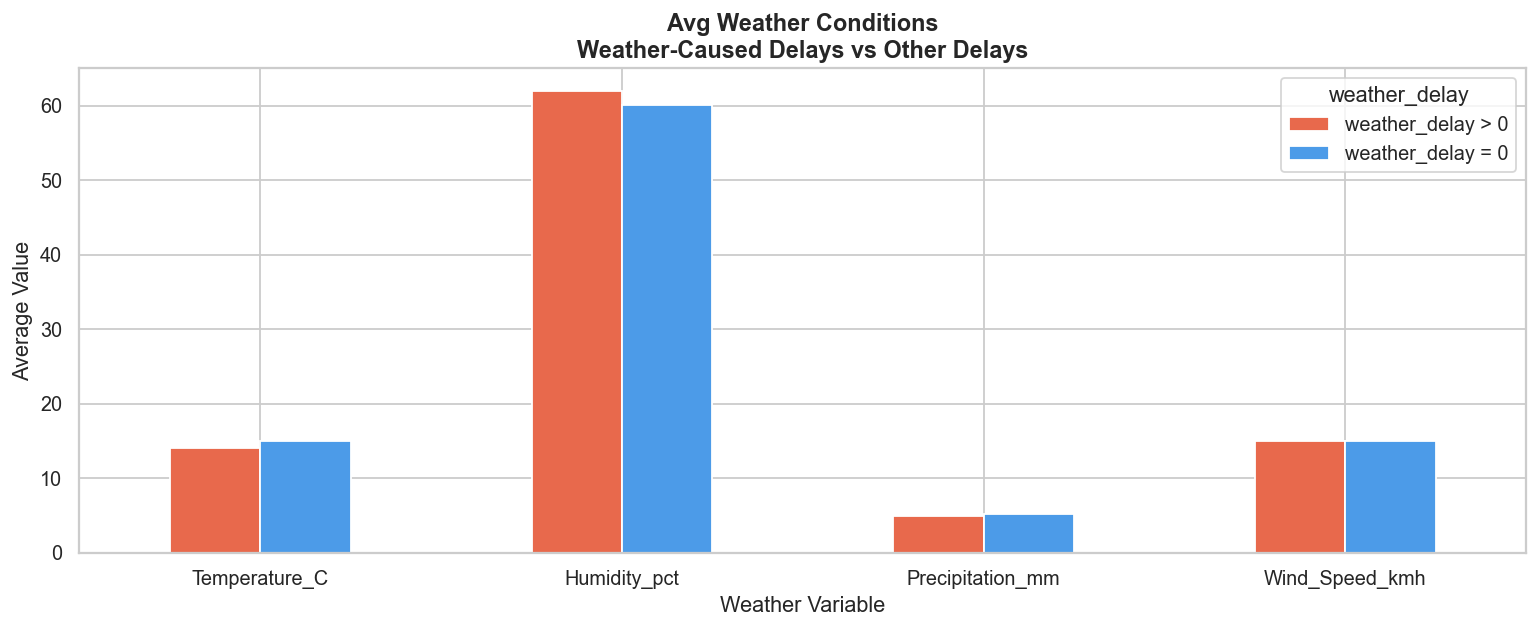

In [7]:
avg_wx    = df_wx_sensor[weather_vars].mean()
avg_no_wx = df_no_wx_sensor[weather_vars].mean()

avg_compare = pd.DataFrame({
    'weather_delay > 0': avg_wx,
    'weather_delay = 0': avg_no_wx
})
print('Average sensor conditions (IS_Delay=1 flights):')
print(avg_compare.round(2).to_string())

avg_compare.plot(kind='bar', figsize=(12, 5),
                 color=['#E8694C', '#4C9BE8'], edgecolor='white', rot=0)
plt.title('Avg Weather Conditions\nWeather-Caused Delays vs Other Delays', fontsize=13, fontweight='bold')
plt.ylabel('Average Value')
plt.xlabel('Weather Variable')
plt.legend(title='weather_delay')
plt.tight_layout()
plt.show()

## 7. Weather-Caused Delay Rate by Season

        total_flights  total_delayed  wx_delayed  wx_pct_of_all  wx_pct_of_delayed
Season                                                                            
Winter         312859          90585        4744           1.52               5.24
Spring         340192         104957        4607           1.35               4.39
Summer         350877         124537        6061           1.73               4.87
Fall           339515          73617        2000           0.59               2.72


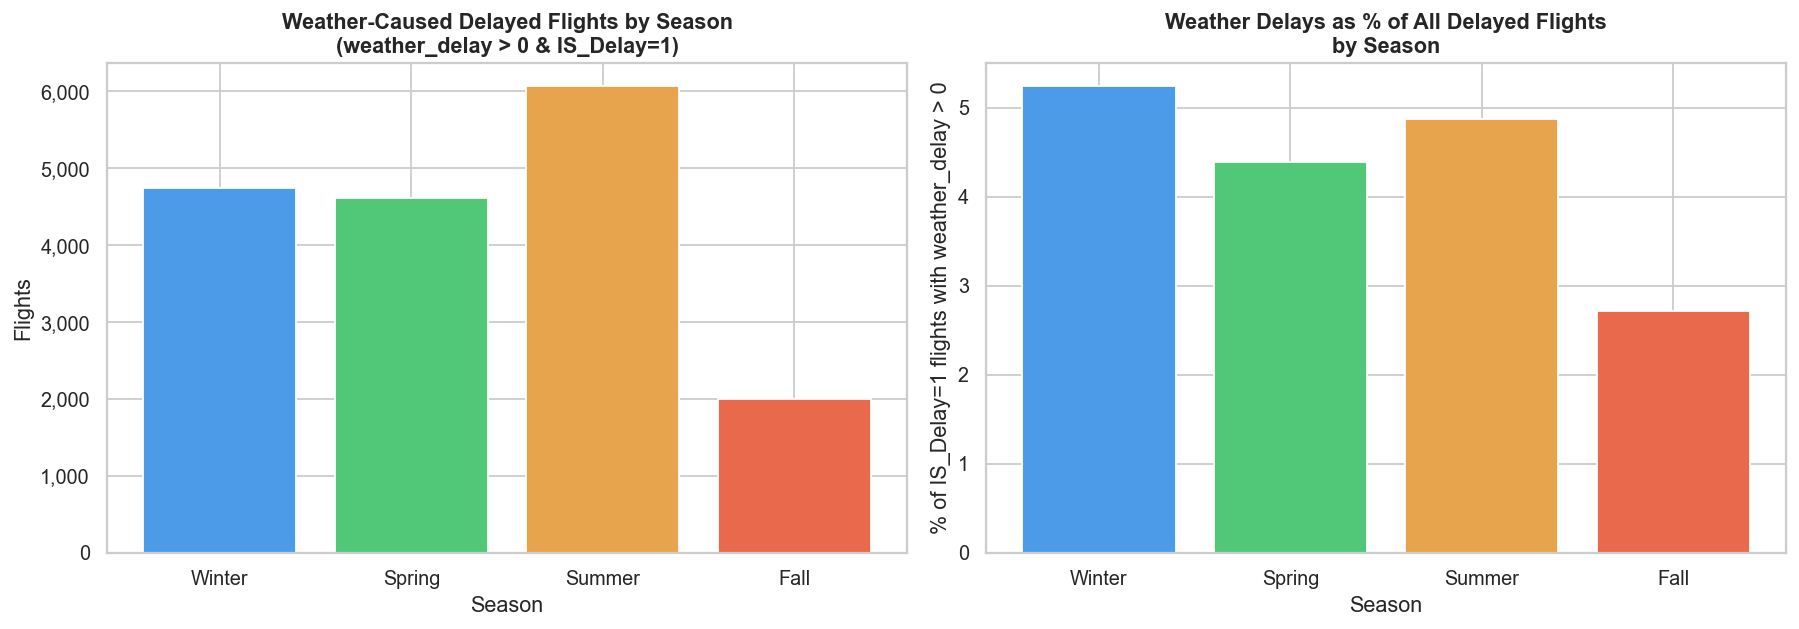

In [8]:
season_order  = ['Winter', 'Spring', 'Summer', 'Fall']
season_colors = ['#4C9BE8', '#50C878', '#E8A44C', '#E8694C']

season_stats = (
    df.groupby('Season')
    .agg(
        total_flights   =('IS_Delay',       'count'),
        total_delayed   =('IS_Delay',       'sum'),
        wx_delayed      =('weather_delay',  lambda x: (x > 0).sum())
    )
    .reindex(season_order)
)
season_stats['wx_pct_of_all']     = season_stats['wx_delayed'] / season_stats['total_flights']  * 100
season_stats['wx_pct_of_delayed'] = season_stats['wx_delayed'] / season_stats['total_delayed']  * 100

print(season_stats.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(season_stats.index, season_stats['wx_delayed'],
            color=season_colors, edgecolor='white')
axes[0].set_title('Weather-Caused Delayed Flights by Season\n(weather_delay > 0 & IS_Delay=1)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Flights')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].bar(season_stats.index, season_stats['wx_pct_of_delayed'],
            color=season_colors, edgecolor='white')
axes[1].set_title('Weather Delays as % of All Delayed Flights\nby Season', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% of IS_Delay=1 flights with weather_delay > 0')

for ax in axes:
    ax.set_xlabel('Season')
plt.tight_layout()
plt.show()

## 8. Weather Delay Minutes by Season (Boxplot)

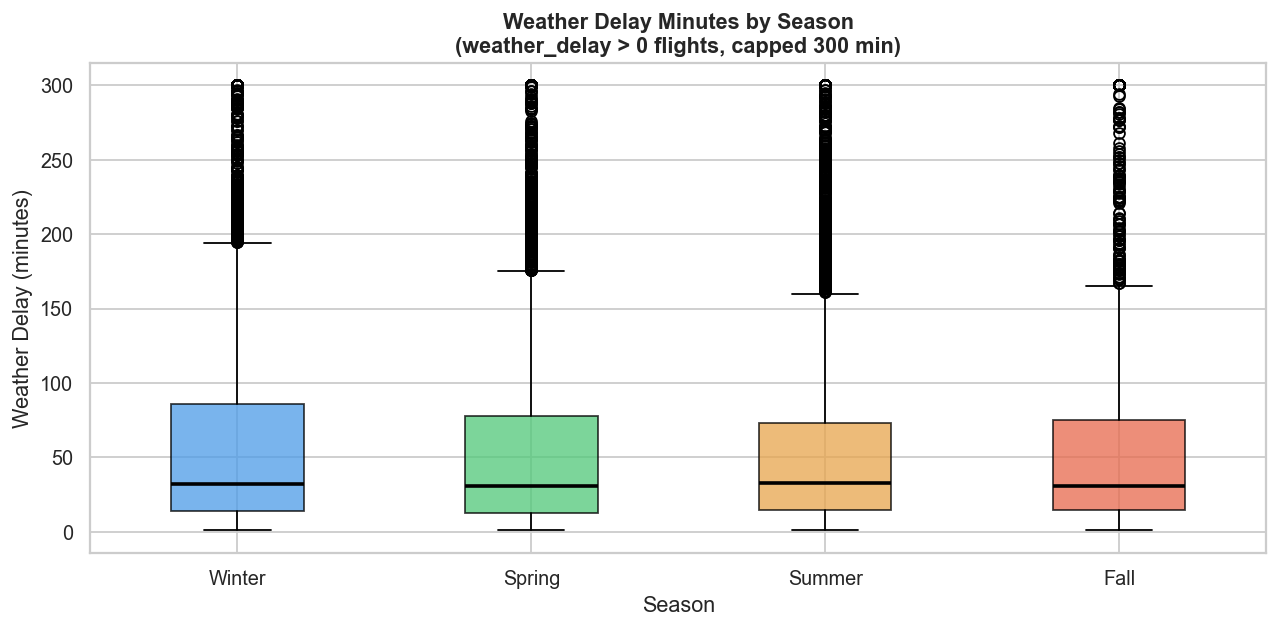

Median weather delay minutes by season:
  Winter  : 32.0 min  (mean: 65.9)
  Spring  : 31.0 min  (mean: 59.3)
  Summer  : 33.0 min  (mean: 57.3)
  Fall    : 31.0 min  (mean: 60.3)


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

season_data = [df_weather_delayed[df_weather_delayed['Season'] == s]['weather_delay'].clip(upper=300).dropna()
               for s in season_order]
bp = ax.boxplot(season_data, labels=season_order, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], season_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title('Weather Delay Minutes by Season\n(weather_delay > 0 flights, capped 300 min)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Weather Delay (minutes)')
plt.tight_layout()
plt.show()

print('Median weather delay minutes by season:')
for s, d in zip(season_order, season_data):
    print(f'  {s:<8}: {d.median():.1f} min  (mean: {d.mean():.1f})')

## 9. Temperature Bins vs Weather Delay Rate

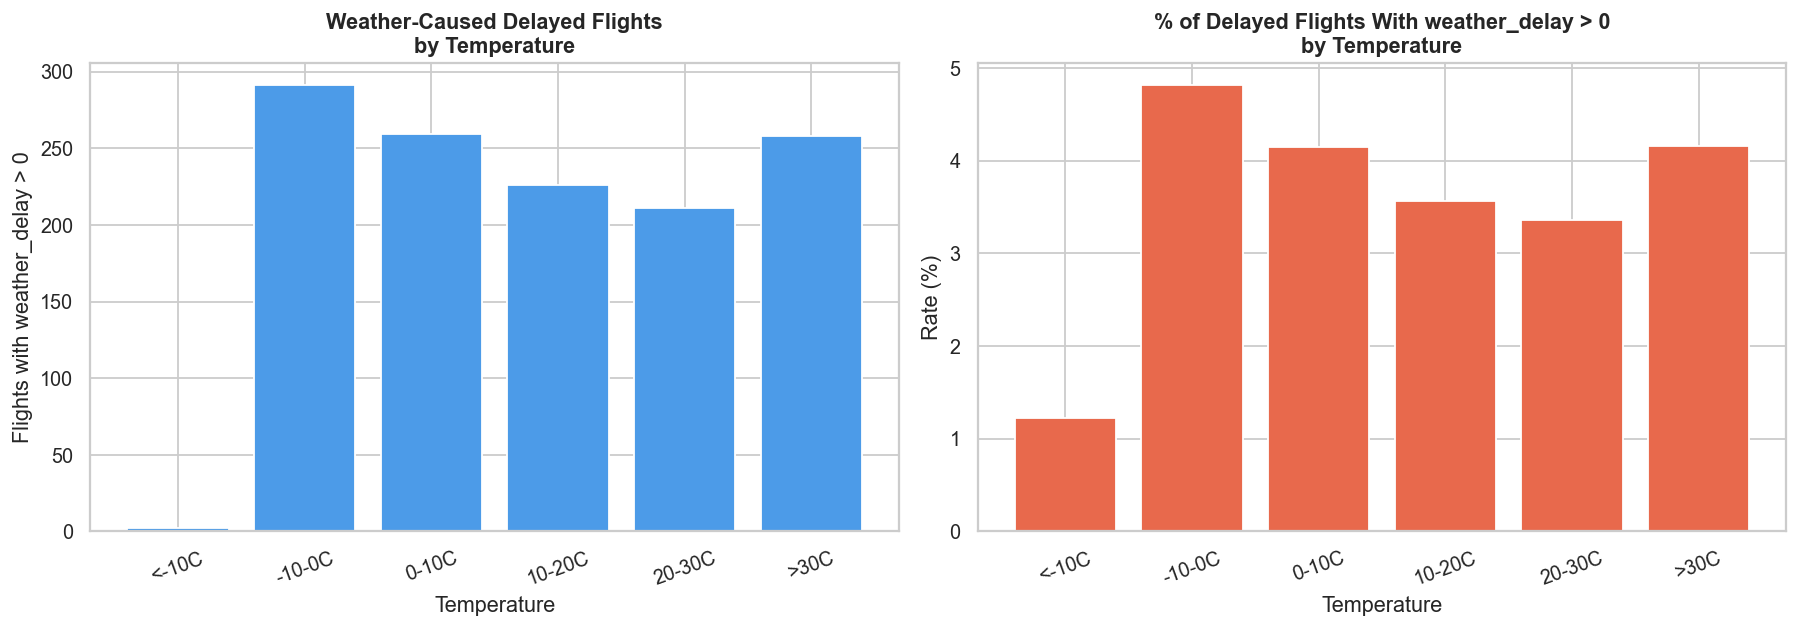

          wx_delayed  total_delayed  rate  rate_pct
Temp_Bin                                           
<-10C              2            164  0.01      1.22
-10-0C           291           6048  0.05      4.81
0-10C            259           6241  0.04      4.15
10-20C           226           6345  0.04      3.56
20-30C           211           6275  0.03      3.36
>30C             258           6207  0.04      4.16


In [10]:
# Use all delayed flights with sensor data
df_delayed_sensor = df[(df['IS_Delay'] == 1) & (df['Weather_Data_Present'] == 'Yes')].copy()
df_delayed_sensor['wx_caused'] = df_delayed_sensor['weather_delay'] > 0

df_delayed_sensor['Temp_Bin'] = pd.cut(
    df_delayed_sensor['Temperature_C'],
    bins=[-40, -10, 0, 10, 20, 30, 50],
    labels=['<-10C', '-10-0C', '0-10C', '10-20C', '20-30C', '>30C']
)

temp_stats = (
    df_delayed_sensor.groupby('Temp_Bin', observed=True)['wx_caused']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'wx_delayed', 'count': 'total_delayed', 'mean': 'rate'})
)
temp_stats['rate_pct'] = temp_stats['rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(temp_stats.index.astype(str), temp_stats['wx_delayed'],    color='#4C9BE8', edgecolor='white')
axes[0].set_title('Weather-Caused Delayed Flights\nby Temperature', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('Flights with weather_delay > 0')
axes[0].tick_params(axis='x', rotation=20)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].bar(temp_stats.index.astype(str), temp_stats['rate_pct'], color='#E8694C', edgecolor='white')
axes[1].set_title('% of Delayed Flights With weather_delay > 0\nby Temperature', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Temperature')
axes[1].set_ylabel('Rate (%)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()
print(temp_stats.round(2).to_string())

## 10. Precipitation, Wind & Humidity vs Weather Delay Rate

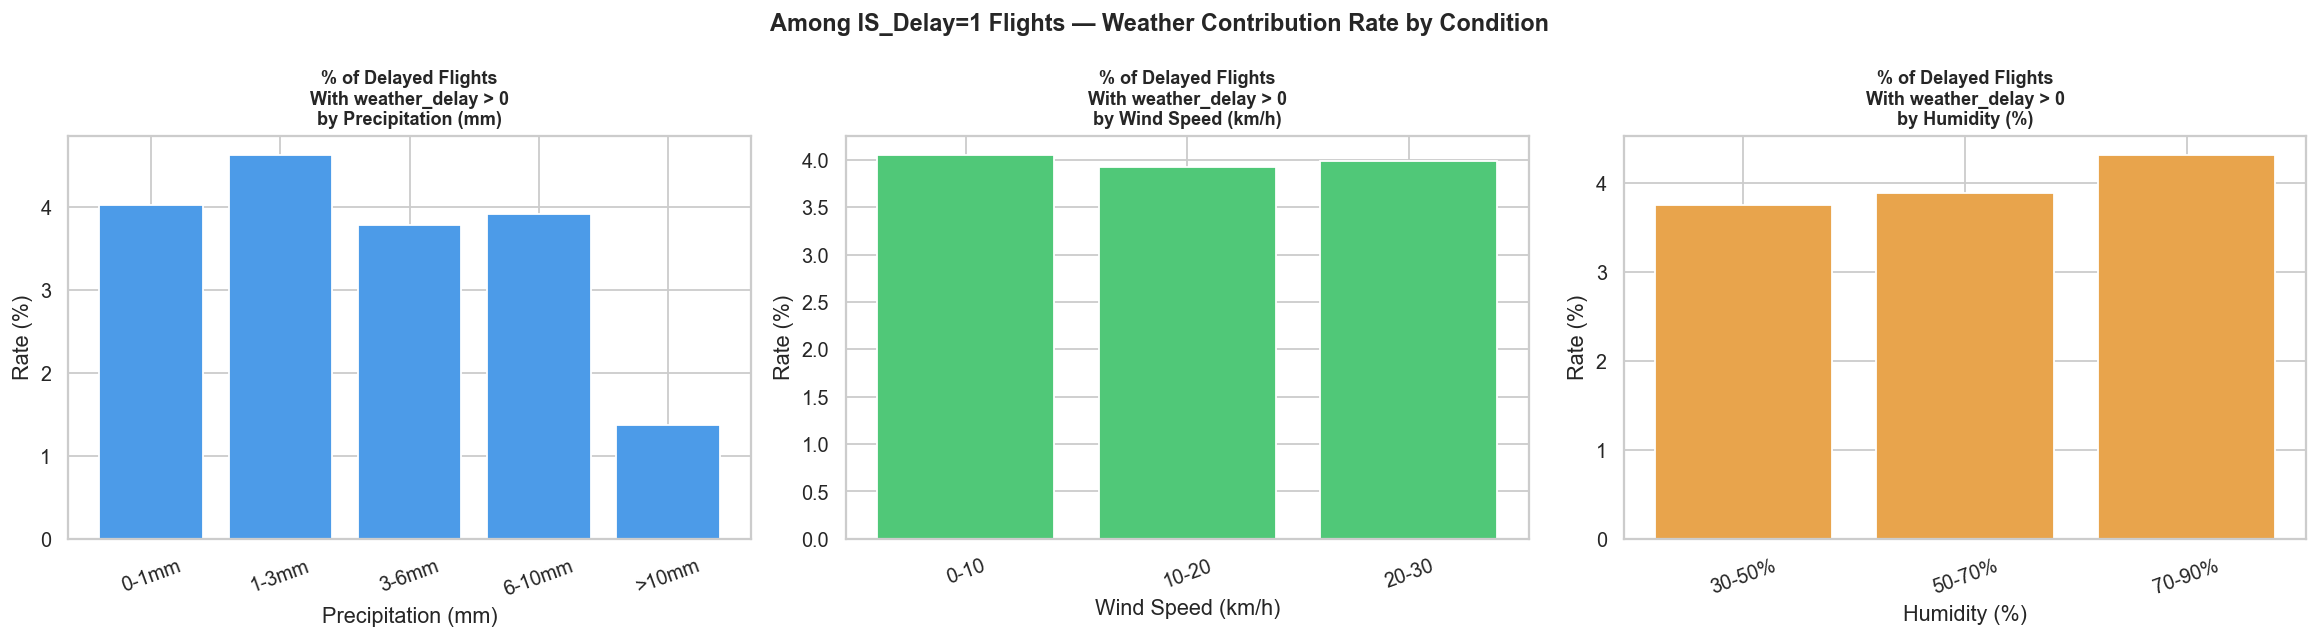

In [11]:
df_delayed_sensor['Precip_Bin'] = pd.cut(
    df_delayed_sensor['Precipitation_mm'],
    bins=[0, 1, 3, 6, 10, 100], labels=['0-1mm','1-3mm','3-6mm','6-10mm','>10mm'], include_lowest=True
)
df_delayed_sensor['Wind_Bin'] = pd.cut(
    df_delayed_sensor['Wind_Speed_kmh'],
    bins=[0, 10, 20, 30, 50, 200], labels=['0-10','10-20','20-30','30-50','>50'], include_lowest=True
)
df_delayed_sensor['Humidity_Bin'] = pd.cut(
    df_delayed_sensor['Humidity_pct'],
    bins=[0, 30, 50, 70, 90, 100], labels=['0-30%','30-50%','50-70%','70-90%','90-100%'], include_lowest=True
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title, color in [
    (axes[0], 'Precip_Bin',   'Precipitation (mm)', '#4C9BE8'),
    (axes[1], 'Wind_Bin',     'Wind Speed (km/h)',   '#50C878'),
    (axes[2], 'Humidity_Bin', 'Humidity (%)',         '#E8A44C'),
]:
    rate = df_delayed_sensor.groupby(col, observed=True)['wx_caused'].mean() * 100
    ax.bar(rate.index.astype(str), rate.values, color=color, edgecolor='white')
    ax.set_title(f'% of Delayed Flights\nWith weather_delay > 0\nby {title}', fontsize=10, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Rate (%)')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Among IS_Delay=1 Flights — Weather Contribution Rate by Condition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Correlation: Weather Conditions vs weather_delay Minutes

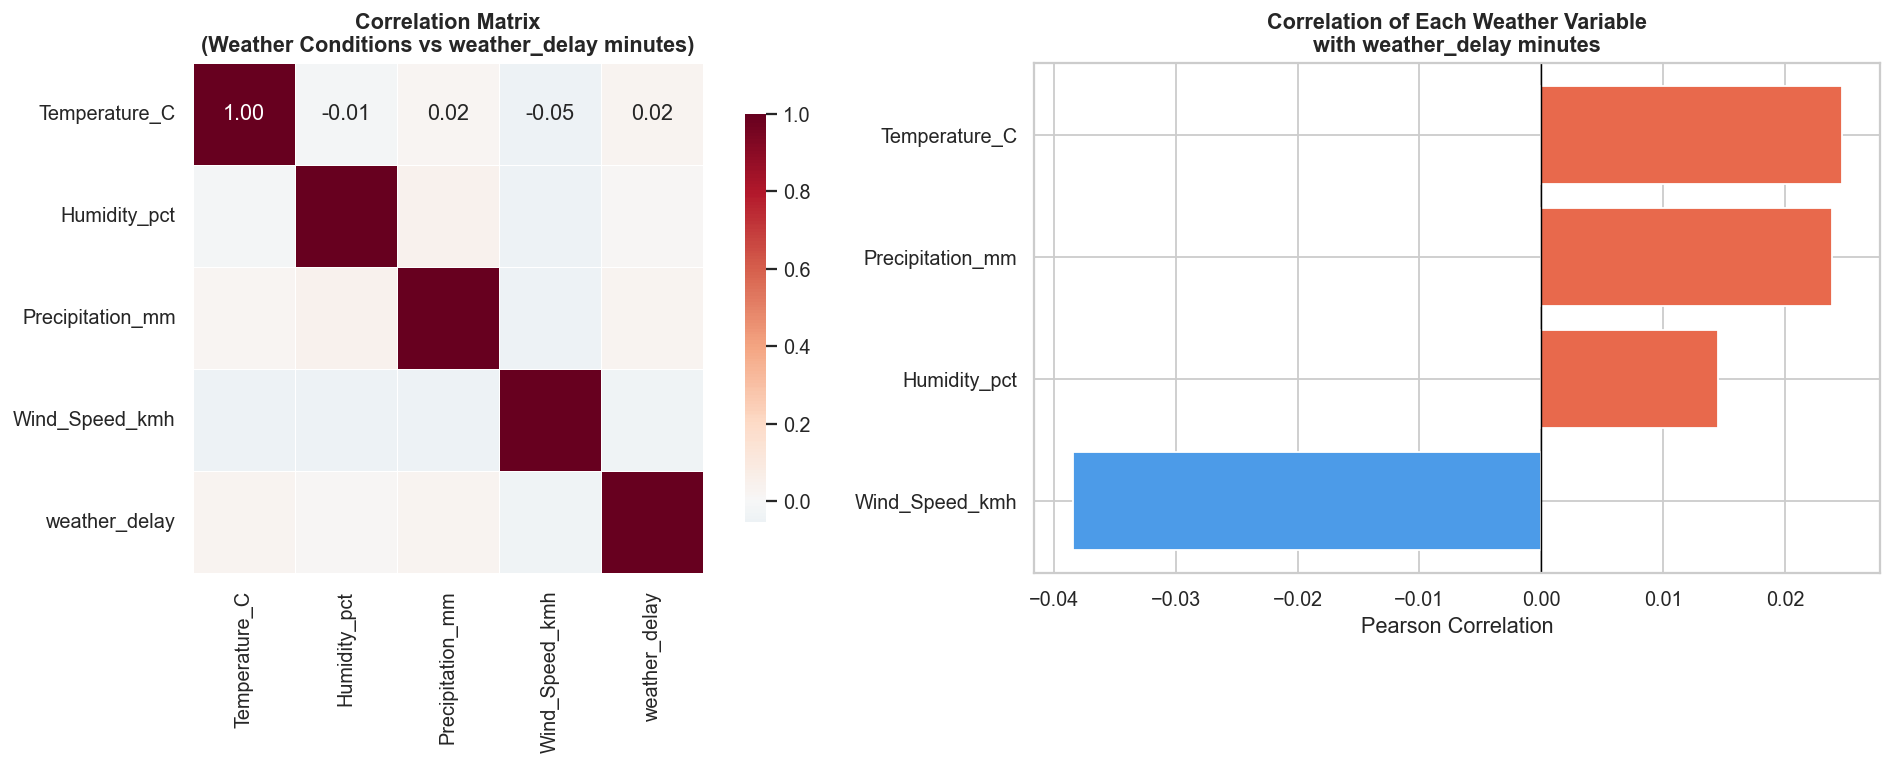

In [12]:
# Among weather-caused delayed flights with sensor data
corr_cols   = weather_vars + ['weather_delay']
corr_matrix = df_wx_sensor[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, square=True, ax=axes[0], linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Correlation Matrix\n(Weather Conditions vs weather_delay minutes)',
                  fontsize=12, fontweight='bold')

weather_corr = corr_matrix['weather_delay'][weather_vars].sort_values()
bar_colors   = ['#E8694C' if v > 0 else '#4C9BE8' for v in weather_corr]
axes[1].barh(weather_corr.index, weather_corr.values, color=bar_colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation of Each Weather Variable\nwith weather_delay minutes',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.show()

## 12. Monthly Trend

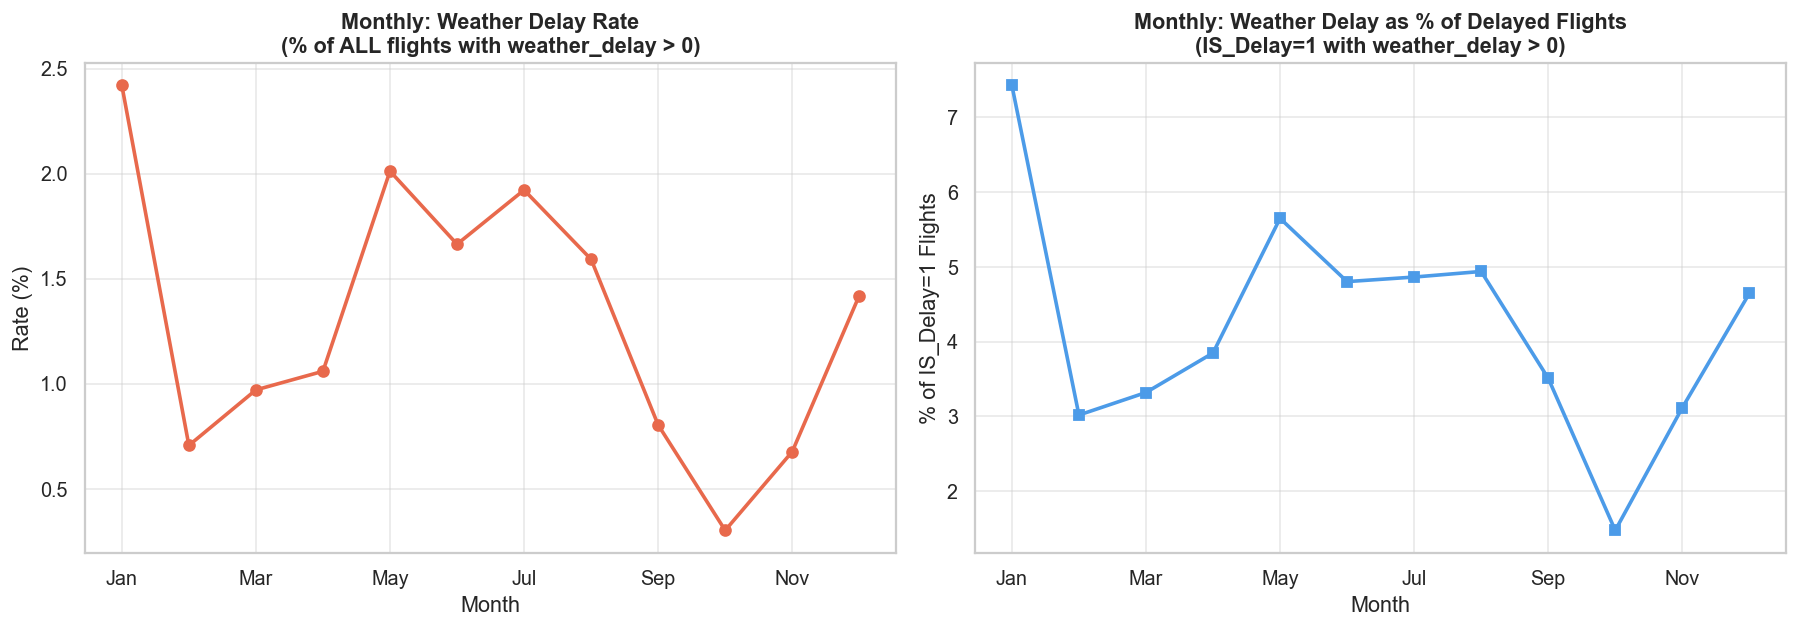

In [13]:
monthly = (
    df.groupby('month')
    .agg(
        total_flights   =('IS_Delay',      'count'),
        total_delayed   =('IS_Delay',      'sum'),
        wx_delayed      =('weather_delay', lambda x: (x > 0).sum())
    )
)
monthly['wx_pct_of_all']     = monthly['wx_delayed'] / monthly['total_flights']  * 100
monthly['wx_pct_of_delayed'] = monthly['wx_delayed'] / monthly['total_delayed']  * 100

month_names   = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly.index = [month_names[i-1] for i in monthly.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly['wx_pct_of_all'].plot(kind='line', marker='o', ax=axes[0], color='#E8694C', linewidth=2)
axes[0].set_title('Monthly: Weather Delay Rate\n(% of ALL flights with weather_delay > 0)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Rate (%)')
axes[0].set_xlabel('Month')
axes[0].grid(True, alpha=0.4)

monthly['wx_pct_of_delayed'].plot(kind='line', marker='s', ax=axes[1], color='#4C9BE8', linewidth=2)
axes[1].set_title('Monthly: Weather Delay as % of Delayed Flights\n(IS_Delay=1 with weather_delay > 0)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('% of IS_Delay=1 Flights')
axes[1].set_xlabel('Month')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## 13. Top Cities with Most Weather-Caused Delays

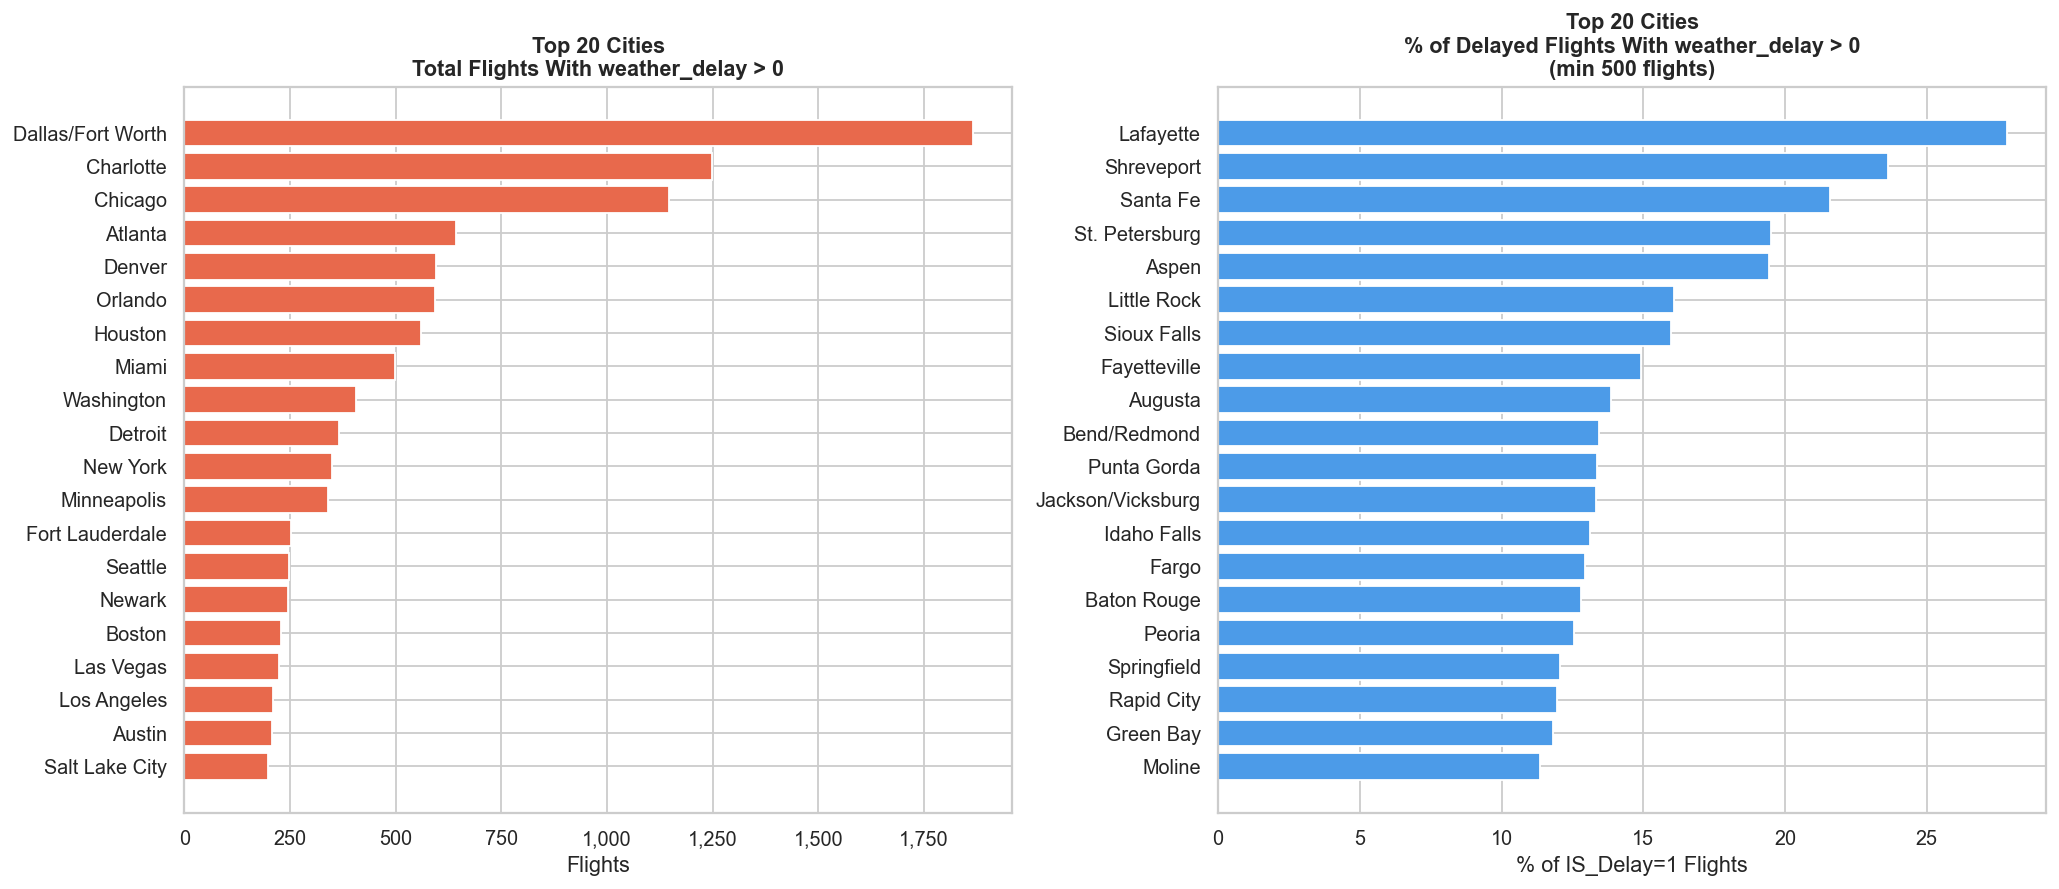

In [14]:
city_stats = (
    df.groupby('origin_city')
    .agg(
        total_flights   =('IS_Delay',      'count'),
        total_delayed   =('IS_Delay',      'sum'),
        wx_delayed      =('weather_delay', lambda x: (x > 0).sum())
    )
    .assign(
        wx_pct_of_flights  = lambda x: x['wx_delayed'] / x['total_flights']  * 100,
        wx_pct_of_delayed  = lambda x: x['wx_delayed'] / x['total_delayed']  * 100
    )
    .sort_values('wx_delayed', ascending=False)
)

top20      = city_stats.head(20)
top20_rate = (city_stats[city_stats['total_flights'] >= 500]
              .sort_values('wx_pct_of_delayed', ascending=False).head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top20.index[::-1], top20['wx_delayed'][::-1], color='#E8694C', edgecolor='white')
axes[0].set_title('Top 20 Cities\nTotal Flights With weather_delay > 0', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Flights')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].barh(top20_rate.index[::-1], top20_rate['wx_pct_of_delayed'][::-1], color='#4C9BE8', edgecolor='white')
axes[1].set_title('Top 20 Cities\n% of Delayed Flights With weather_delay > 0\n(min 500 flights)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('% of IS_Delay=1 Flights')

plt.tight_layout()
plt.show()

## 14. Summary

In [15]:
print('='*65)
print('              WEATHER EDA — KEY FINDINGS SUMMARY')
print('='*65)
print(f'Total flights                              : {total:>12,}')
print(f'Delayed flights        (IS_Delay=1)        : {total_delayed:>12,}  ({total_delayed/total*100:.1f}%)')
print(f'Weather-caused delays  (weather_delay > 0) : {total_wx_delayed:>12,}  ({total_wx_delayed/total_delayed*100:.1f}% of delayed)')
print(f'Avg weather delay mins (when > 0)          : {df_weather_delayed["weather_delay"].mean():>11.1f} min')
print(f'Median weather delay mins (when > 0)       : {df_weather_delayed["weather_delay"].median():>11.1f} min')
print(f'Worst season (wx % of delayed)             : {season_stats["wx_pct_of_delayed"].idxmax():>12}')
print(f'Best  season (wx % of delayed)             : {season_stats["wx_pct_of_delayed"].idxmin():>12}')
print(f'Top city (most weather-caused delays)      : {city_stats.index[0]:>12}')
print('='*65)

              WEATHER EDA — KEY FINDINGS SUMMARY
Total flights                              :    1,343,443
Delayed flights        (IS_Delay=1)        :      393,696  (29.3%)
Weather-caused delays  (weather_delay > 0) :       17,412  (4.4% of delayed)
Avg weather delay mins (when > 0)          :        69.7 min
Median weather delay mins (when > 0)       :        32.0 min
Worst season (wx % of delayed)             :       Winter
Best  season (wx % of delayed)             :         Fall
Top city (most weather-caused delays)      : Dallas/Fort Worth
